In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.special import jv, struve
from sigproc import get_phase_shift_filter, get_lp_filter, dwv
import csv

%load_ext autoreload
%autoreload 2

plt.style.use('dark_background')

In [2]:
##### Section: constants #####

speed_of_light = 3.0E8
w0 = 2.0*np.pi* 0.0E9
w  = 2.0*np.pi* 2.0E9 # around this frequency, the theory describes the results well
h  = 2.0*np.pi* 8.5E9
rho0 = np.radians(0.25) # source angular radius
time_step      = 1.0/(2.0*10.0E9) # 10.0E9 Hz is the sampling frequency

mu, sigma     = 0.0, 1.0   # parameters for the white noise generator
sample_size   = int(2**12) # length of the time series sample for the computation (2**12 - 2**13 seems to be a maximum for a regular computer)
realizations  = 3          # number of realizations for an ensemble averating of the final results
core_seed     = 95646      # the main seed required for reproducibility
source_n_size = 20         # number of points along one axis in the initial grid for the source cloud point
all_baselines   = np.linspace(0.0, 30.0, 31)   # baselines used for the numerical computations
dense_baselines = np.linspace(0.001, 30.0, 300) # baselines used to plot theoretical results

In [3]:
##### Section: simulation #####

In [4]:
central_freq = (w/(2.0*np.pi))/10.0E9
print(central_freq, "(", central_freq - 0.02, central_freq + 0.02, ")")

# Filters for comparison against the classical correlation (result of the van Cittert-Zernike theorem)
hp_filter = get_lp_filter(1.00*np.pi) - get_lp_filter((central_freq - 0.02)*np.pi) # left freq cutoff
lp_filter = get_lp_filter((central_freq + 0.02)*np.pi)                             # right freq cufoff

0.2 ( 0.18000000000000002 0.22 )


(284, 2) 1963.4954084936207


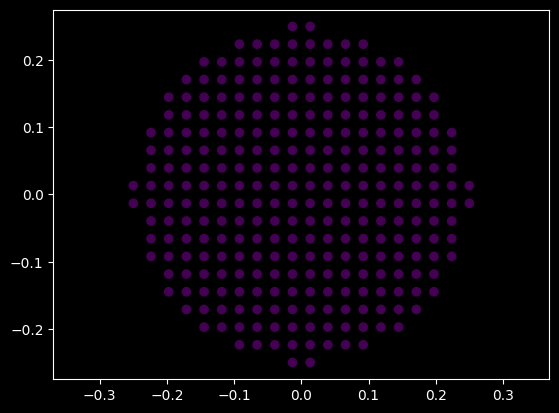

In [5]:
# preparation of pairs of angles of the source poin locations
# all angles here are in degrees for convenient plotting

source_points = []
for alpha_ii in np.linspace(-np.degrees(rho0), np.degrees(rho0), source_n_size):
    for beta_ii in np.linspace(-np.degrees(rho0), np.degrees(rho0), source_n_size):
        source_points.append([alpha_ii, beta_ii])
source_points = np.array(source_points)

# mask selection to make a round source
source_points_init = source_points
source_points = []
for point in source_points_init:
    alpha, beta = point
    distance = alpha**2 + beta**2
    if distance < 0.25**2 + 0.001:
        source_points.append([alpha, beta])
source_points = np.array(source_points)


def intensity(x,y):
    # return np.exp(-x**2/0.1)*np.exp(-y**2/0.1)
    # return x*y
    return 1.0

source_intensity = np.array([intensity(point[0], point[1]) for point in source_points])

print(source_points.shape, 25*25*np.pi)
plt.scatter(source_points[:,0], source_points[:,1], c=(source_intensity/np.max(source_intensity))/255.)
plt.gca().axis('equal')
plt.show()

In [6]:
# preparing individual seed ids for every point of the source

rng = np.random.default_rng(core_seed)
s = rng.integers(0, high=999999, size=3*source_points.shape[0])
print(s.shape)
unq = np.unique(s)
source_seeds = unq[:source_points.shape[0]]
print(source_points.shape)
print(source_seeds.shape)

(852,)
(284, 2)
(284,)


In [7]:
# Main loop to produce initial time series for further computaions

total_signal_all = []
total_signal_filtered_all = []
for realization in range(realizations):
    print('realization=', realization)
    total_signal_realization = []
    total_signal_filtered_realization = []
    for baseline in all_baselines:
        total_signal = np.zeros(sample_size)
        total_signal_filtered = np.zeros(sample_size) # to compute classical correlation at a certain freq channel
        for ii in range(source_points.shape[0]):
            pair, seed = source_points[ii], source_seeds[ii]
            intensity = source_intensity[ii]
            alpha, beta = pair
            incoming_angle_alpha, incoming_angle_beta = np.radians(alpha), np.radians(beta)
            norm_vector_x = np.sin(incoming_angle_alpha)
            norm_vector_y = np.sin(incoming_angle_beta)
            norm_vector_z = 1.0
            N = np.sqrt(1.0 + norm_vector_x**2 + norm_vector_y**2)
            norm_vector_x = norm_vector_x/N
            norm_vector_y = norm_vector_y/N
            norm_vector_z = norm_vector_z/N

            geometrical_delay_distance = norm_vector_x*baseline
            time_delay = geometrical_delay_distance / speed_of_light
            time_delay_steps = time_delay/time_step

            rng = np.random.default_rng(realization + seed)
            s = rng.normal(mu, sigma, sample_size*2)
            s = s*intensity

            s_shifted_init     = signal.convolve(s,              np.flip(get_phase_shift_filter(time_delay_steps)), mode='same')
            tmp = s_shifted_init[2000:2000+sample_size] # cutting off extra length to get the desired time series length
            total_signal += tmp

            s_shifted_filtered = signal.convolve(s_shifted_init,     np.flip(lp_filter), mode='same')
            s_shifted_filtered = signal.convolve(s_shifted_filtered, np.flip(hp_filter), mode='same') # trancating the edge effect only here
            tmp = s_shifted_filtered[2000:2000+sample_size] # cutting off extra length
            total_signal_filtered += tmp
        total_signal_realization.append(total_signal)
        total_signal_filtered_realization.append(total_signal_filtered)
    total_signal_all.append(total_signal_realization)
    total_signal_filtered_all.append(total_signal_filtered_realization)
total_signal_all = np.array(total_signal_all)
total_signal_filtered_all = np.array(total_signal_filtered_all)
print('done...')

realization= 0
realization= 1
realization= 2
done...


In [8]:
# Computing classical correlation

corr_filt_realizations = []
for realization in range(realizations):
    ref_signal = total_signal_filtered_all[realization, 0, :] ##, 1000:(s_line_all_realizations_sum.shape[2]-1000)]
    
    # computing correlations relative to the reference signal at x = 0 m.
    corr_filt = []
    for ii in range(0, total_signal_filtered_all.shape[1]):
        corr = np.sum(ref_signal*total_signal_filtered_all[realization, ii, : ])
        corr_filt.append(corr)
    corr_filt = np.array(corr_filt)
    corr_filt_realizations.append(corr_filt)
corr_filt_realizations = np.array(corr_filt_realizations)

In [9]:
# Computing the Wigner functions for individual time series and selecting a temporal variation of it at a channel correspoding to the desired frequency

wigner_channel = int(sample_size*((w/(2.0*np.pi))/10.0E9))

window = signal.windows.boxcar(sample_size)
wv_plane_realizations = []
for realization in range(realizations):
    print('realization', realization)
    wv_plane = []
    for item in total_signal_all[realization]:
        tmp = dwv(item*window, item*window)[:, wigner_channel]
        wv_plane.append(tmp)
        del tmp
    wv_plane = np.array(wv_plane)
    wv_plane_realizations.append(wv_plane)
wv_plane_realizations = np.array(wv_plane_realizations)
print('done...')

realization 0
realization 1
realization 2
done...


In [10]:
# Computing the Wigner correlations (correlation of the "central" time series with the time series at provided baselines)

corr_wv_realizations = []
for realization in range(realizations):
    ref_signal = wv_plane_realizations[realization, 0, :]
    corr_wv = []
    for ii in range(0, wv_plane_realizations.shape[1]):
        corr = np.sum(ref_signal.real *wv_plane_realizations[realization, ii, :].real)
        corr_wv.append(corr)
    corr_wv = np.array(corr_wv)
    corr_wv_realizations.append(corr_wv)
corr_wv_realizations = np.array(corr_wv_realizations)

corr_wv_mean = np.sum(corr_wv_realizations, axis=0)
corr_wv_mean = corr_wv_mean/corr_wv_mean[0]

In [11]:
##### Section: theory #####

In [12]:
# Theoretical result for the classical correlation (the correlation pattern due to the van Cittert Zernike theorem)

wavelength = (central_freq*(0.5*(1.0/time_step)))
wavelength = speed_of_light / wavelength
alpha_source = rho0
v = 2.0*np.pi * alpha_source / wavelength
v = v * dense_baselines
vcz_theory = 2.0*jv(1, v)/v

In [13]:
# Wigner correlation, self-interference contribution

def m_n(fn, rho0, r):
    # r = x
    N = 4.0*np.pi*speed_of_light*speed_of_light/(fn*r*r) ## 1/2??? seems like a mistake
    z = (2.0*fn/speed_of_light)*r*rho0
    V = z*jv(0, z) + 0.5*np.pi*z*(jv(1, z)*struve(0, z) - jv(0, z)*struve(1, z))
    f = N*(-0.25*z*jv(1, z) + 0.25*z*V)
    return f

def M(a, b, c, d, w, r):
    res = np.zeros(r.shape[0])

    f1 = np.abs(w - a) + d + c + b
    f2 = np.abs(w - a) + d + c - b
    f3 = np.abs(w - a) + d - c + b
    f4 = np.abs(w - a) + d - c - b
    f5 = np.abs(w - a) - d + c + b
    f6 = np.abs(w - a) - d + c - b
    f7 = np.abs(w - a) - d - c + b
    f8 = np.abs(w - a) - d - c - b
    f = [f1, f2, f3, f4, f5, f6, f7, f8]

    g1 = np.abs(w + a) + d + c + b
    g2 = np.abs(w + a) + d + c - b
    g3 = np.abs(w + a) + d - c + b
    g4 = np.abs(w + a) + d - c - b
    g5 = np.abs(w + a) - d + c + b
    g6 = np.abs(w + a) - d + c - b
    g7 = np.abs(w + a) - d - c + b
    g8 = np.abs(w + a) - d - c - b
    g = [g1, g2, g3, g4, g5, g6, g7, g8]

    N = -0.25*np.pi # Eg. 70
    for fn in f:
        tmp = N*m_n(fn, rho0, r)/8.0
        res = res + tmp

    for fn in g:
        tmp = N*m_n(fn, rho0, r)/8.0
        res = res + tmp

    return res

def aa_circ(r, w, w0, h):
    A  = M(0, h, w, w0, w, r)
    B1 = M(h,  0, w, w0, w, r)
    B2 = M(w,  0, h, w0, w, r)
    B3 = M(w0, 0, h, w, w, r)
    C1 = M(w-h,  0, 0, w0, w, r)
    C2 = M(w+h,  0, 0, w0, w, r)
    C3 = M(w0-h, 0, 0, w, w, r)
    C4 = M(w0+h, 0, 0, w, w, r)
    C5 = M(w0-w, 0, 0, h, w, r)
    C6 = M(w0+w, 0, 0, h, w, r)
    D1 = M(w0-w-h, 0, 0, 0, w, r)
    D2 = M(w0-w+h, 0, 0, 0, w, r)
    D3 = M(w0+w-h, 0, 0, 0, w, r)
    D4 = M(w0+w+h, 0, 0, 0, w, r)

    res = A - B1 + B3 + B3 - 0.5*(C1 + C2 + C3 + C4 - C5 - C6) - 0.25*(D1 + D2 + D3 + D4)
    return res

In [14]:
# Wigner interference: cross-interference contribution

def f(a, w):
    return -0.5*np.pi*(np.abs(w - a) + np.abs(w + a))

def F(w, w0, h):
    A  = f(0, w)
    B1 = f(h, w)
    B2 = f(w, w)
    B3 = f(w0, w)
    C1 = f(w-h, w)
    C2 = f(w+h, w)
    C3 = f(w0-h, w)
    C4 = f(w0+h, w)
    C5 = f(w0-w, w)
    C6 = f(w0+w, w)
    D1 = f(w0-w-h, w)
    D2 = f(w0-w+h, w)
    D3 = f(w0+w-h, w)
    D4 = f(w0+w+h, w)

    res = A - B1 + B3 + B3 - 0.5*(C1 + C2 + C3 + C4 - C5 - C6) - 0.25*(D1 + D2 + D3 + D4)
    return res

def L(w, r):
    wavelength = 2.0*np.pi*speed_of_light/w
    k = 2.0*np.pi / wavelength
    v = 2 * k * rho0 * r
    N = np.pi * rho0 * rho0
    return N * 2.0*jv(1, v)/v

def ab_circ(r, w, w0, h):
    return F(w, w0, h)*L(w, r)

In [15]:
aa_theory = aa_circ(dense_baselines, w, w0, h)
ab_theory = ab_circ(dense_baselines, w, w0, h)

In [16]:
np.savetxt('./data/circ_aa_theory.txt',    aa_theory, delimiter=',')
np.savetxt('./data/circ_ab_theory.txt',    ab_theory, delimiter=',')
np.savetxt('./data/circ_vcz_theory.txt',   vcz_theory, delimiter=',')
np.savetxt('./data/circ_corr_wv_mean.txt', corr_wv_mean, delimiter=',')
np.savetxt('./data/circ_dense_baselines.txt', dense_baselines, delimiter=',')
np.savetxt('./data/circ_baselines.txt', all_baselines, delimiter=',')